# Python training - week 1

This is the first (maybe of many?) installments of our python problem setting. The aim of these tasks is to allow CCC colleagues to put their python skills to the test. We will hold a dedicated session for each problem to run through solutions and talk through difficulties that people may have encountered.

#### Task

Write a workflow which does the following:

- Reads in the 'total_generation.csv' and 'renewable_generation_by_source.csv' data from ./data/inputs/

- Calculates the renewable share of total generation across the full time period.

- Finds the first year in which renewable generation exceeded 40% of total generation.

- Finds the compound annual growth rate in renewable share of generation between 2008 and 2025.

- Uses this to extrapolate out what the proportion of renewable generation would be expected to be on current trends in 2030.

- Saves a csv in the ./data/outputs folder which contains the total generation, total renewable generation, and proportion of generation from renewable shares for 2000 - 2025.

- Bonus: 
    * Extrapolates out the full timeseries to 2030 based on the calculated compound annual growth rate.
    * Makes a plot of the historic and extrapolated data, showing the two as separate lines. Use ```matplotlib.pyplot``` for this.

#### Example solution below

In [1]:
import pandas as pd
import numpy as np

In [3]:
# reading in the two dataframes

total_df = pd.read_csv("./data/inputs/total_generation.csv")
renewable_df = pd.read_csv("./data/inputs/renewable_generation_by_source.csv")

In [4]:
# inspecting each one in turn

total_df.head()

,date,total_generation_twh
0,2000,377.06
1,2001,384.77
2,2002,387.24
3,2003,398.21
4,2004,393.92


In [5]:
renewable_df.head()

,date,bioenergy_generation_twh,hydro_generation_twh,other renewables_generation_twh,solar_generation_twh,wind_generation_twh
0,2000,3.88,5.09,0.0,0.0,0.94
1,2001,4.53,4.05,0.0,0.0,0.96
2,2002,5.08,4.79,0.0,0.0,1.25
3,2003,6.17,3.23,0.0,0.0,1.29
4,2004,7.36,4.84,0.0,0.0,1.94


In [6]:
# setting the "date" column as index in both to make joining easier later

total_df = total_df.set_index("date")
renewable_df = renewable_df.set_index("date")

In [ ]:
# getting total renewable generation as a new column

renewable_df["total_renewable_generation_twh"] = renewable_df.sum(axis=1)

renewable_df.tail()

,bioenergy_generation_twh,hydro_generation_twh,other renewables_generation_twh,solar_generation_twh,wind_generation_twh,total_renewable_generation_twh
date,,,,,,
2000,3.88,5.09,0.00,0.00,0.94,9.91
2001,4.53,4.05,0.00,0.00,0.96,9.54
2002,5.08,4.79,0.00,0.00,1.25,11.12
2003,6.17,3.23,0.00,0.00,1.29,10.69
2004,7.36,4.84,0.00,0.00,1.94,14.14
2005,9.10,4.92,0.00,0.01,2.90,16.93
2006,9.28,4.59,0.00,0.01,4.22,18.10
2007,9.32,5.08,0.00,0.01,5.27,19.68
2008,9.65,5.14,0.00,0.02,7.13,21.94


In [8]:
# joining the two dataframes together - note we don't actually have to do this 

combined_df = total_df.join(renewable_df["total_renewable_generation_twh"])

combined_df.tail()

,total_generation_twh,total_renewable_generation_twh
date,,
2021,307.90,122.49
2022,324.58,135.06
2023,292.53,135.67
2024,284.16,143.92
2025,292.78,152.39


In [9]:
# calculating the share of generation as a new column

combined_df["renewable_proportion_of_gen"] = combined_df["total_renewable_generation_twh"] / combined_df["total_generation_twh"]

combined_df.tail()

,total_generation_twh,total_renewable_generation_twh,renewable_proportion_of_gen
date,,,
2021,307.90,122.49,0.397824
2022,324.58,135.06,0.416107
2023,292.53,135.67,0.463781
2024,284.16,143.92,0.506475
2025,292.78,152.39,0.520493


In [10]:
# finding the earliest date for which renewables exceeded 40%

exceeded_forty_perecent = combined_df["renewable_proportion_of_gen"] > 0.4

all_years = combined_df.loc[exceeded_forty_perecent]
first_year = all_years.index[0]

print(f"The first year in which renewables exceeded 40% of generation was {first_year}")

The first year in which renewables exceeded 40% of generation was 2020


In [ ]:
# calculating the CAGR using the relevant formula

start_year = 2008
end_year = 2025
years_elapsed = end_year - start_year 

starting_value = combined_df["renewable_proportion_of_gen"][start_year]
end_value = combined_df["renewable_proportion_of_gen"][end_year]

cagr = ((end_value / starting_value) ** (1/years_elapsed) - 1)

np.float64(0.13964505560488183)

In [27]:
# extrapolating out to 2030 with this value
years_to_2030 = 2030 - 2025

projected_value = end_value * ((cagr + 1)**years_to_2030)

projected_value

np.float64(1.0006060300850572)

In [28]:
# exporting the data

combined_df.to_csv("./data/outputs/combined_generation_output.csv")

### Bonus answers below

In [35]:
# Extrapolating the full timeseries

years_to_2030 = np.arange(2025, 2031, 1, dtype=int)
extrapolated_values = []

for year in years_to_2030:
    year_gap = year - end_year
    extrapolated_value = end_value * ((cagr + 1) ** year_gap)
    extrapolated_values.append(extrapolated_value)

extrapolated_values = np.array(extrapolated_values)

In [36]:
# turning this into its own dataframe

extrapolated_2d_array = np.column_stack([years_to_2030, extrapolated_values])
extrapolated_df = pd.DataFrame(extrapolated_2d_array,
                               columns=["date", "extrapolated_renewable_share_of_generation"])

extrapolated_df = extrapolated_df.set_index("date")

In [38]:
# concatenating the two dataframes to get one big dataframe

final_df = pd.concat([combined_df, extrapolated_df])

final_df.head()

,total_generation_twh,total_renewable_generation_twh,renewable_proportion_of_gen,extrapolated_renewable_share_of_generation
date,,,,
2000.0,377.06,9.91,0.026282,NaN
2001.0,384.77,9.54,0.024794,NaN
2002.0,387.24,11.12,0.028716,NaN
2003.0,398.21,10.69,0.026845,NaN
2004.0,393.92,14.14,0.035896,NaN


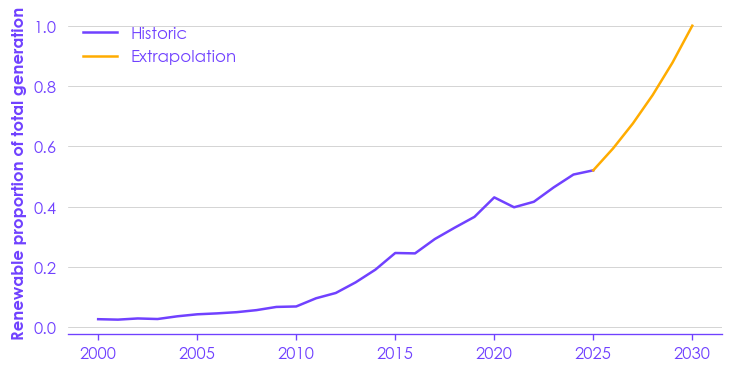

In [40]:
# and plotting the two together
import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
sys.path.append(PROJECT_ROOT)

import matplotlib.pyplot as plt
from utils import theme

fig, axs = plt.subplots()

axs.plot(final_df["renewable_proportion_of_gen"])
axs.plot(final_df["extrapolated_renewable_share_of_generation"])

axs.set_ylabel("Renewable proportion of total generation")
axs.legend(["Historic", "Extrapolation"])